In [10]:
import pandas as pd

fires = pd.read_csv(
    "Fires_202610082057.csv",
    dtype={"DISCOVERY_TIME": "string"}
)

fires["discovery_date"] = pd.to_datetime(fires["discovery_date"])

print("Records:", len(fires))
display(fires.head())

Records: 82357


,FOD_ID,STATE,FIRE_YEAR,raw_discovery_date,discovery_date,DISCOVERY_TIME,LATITUDE,LONGITUDE
0,20023744,CA,2011,2455562.5,2011-01-01,1045,34.271667,-117.466111
1,201107097,CA,2011,2455562.5,2011-01-01,0009,32.927200,-115.127000
2,201190947,CA,2011,2455562.5,2011-01-01,1101,33.918800,-118.275200
3,201197078,CA,2011,2455562.5,2011-01-01,0206,36.197362,-119.362463
4,201196070,CA,2011,2455563.5,2011-01-02,1330,34.005782,-117.448965


In [11]:
fires["missing_time"] = (
    fires["DISCOVERY_TIME"].fillna("").str.strip().eq("")
)

quality_by_year = fires.groupby("FIRE_YEAR").agg(
    total_records=("FOD_ID", "size"),
    missing_time=("missing_time", "sum")
)

quality_by_year["missing_time_pct"] = (
    quality_by_year["missing_time"]
    / quality_by_year["total_records"] * 100
).round(2)

display(quality_by_year)

,total_records,missing_time,missing_time_pct
FIRE_YEAR,,,
2011,8599,22,0.26
2012,7224,65,0.9
2013,8719,7,0.08
2014,6512,19,0.29
2015,7410,50,0.67
2016,7894,11,0.14
2017,9571,36,0.38
2018,9519,28,0.29
2019,6549,95,1.45


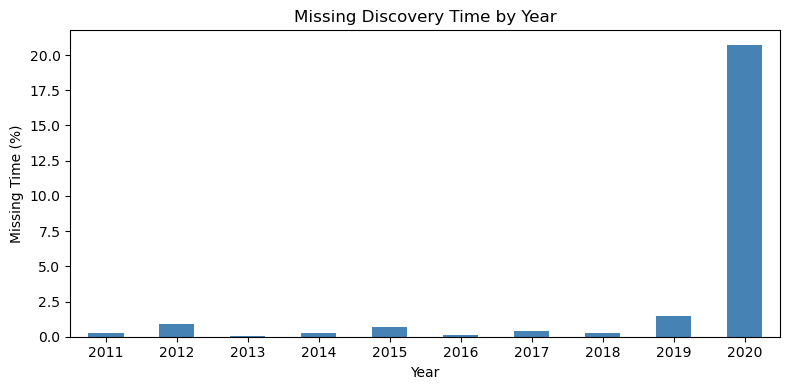

In [12]:
import matplotlib.pyplot as plt

ax = quality_by_year["missing_time_pct"].plot(
    kind="bar", figsize=(8, 4), color="steelblue"
)

ax.set_title("Missing Discovery Time by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Missing Time (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Discovery time is missing for 20.72% of records in 2020, compared with less than 1.5% in every other year.
Removing records with missing times would disproportionately reduce the 2020 sample. We therefore retain these records for daily analysis and leave their discovery times missing. The cause of this change remains unresolved.

In [13]:
# Fixed study area: 39–40°N, 122–121°W
region_fires = fires.loc[
    (fires["LATITUDE"] >= 39)
    & (fires["LATITUDE"] < 40)
    & (fires["LONGITUDE"] >= -122)
    & (fires["LONGITUDE"] < -121)
].copy()

print("Fire records in study area:", len(region_fires))

annual_counts = (
    region_fires.groupby("FIRE_YEAR")
    .size()
    .reindex(range(2011, 2021), fill_value=0)
    .rename("fire_count")
)

display(annual_counts)

Fire records in study area: 4136


FIRE_YEAR
2011    370
2012    394
2013    537
2014    448
2015    460
2016    393
2017    416
2018    459
2019    241
2020    418
Name: fire_count, dtype: int64

In [14]:
%pip install pyproj

import numpy as np
from pyproj import Transformer

# Convert longitude/latitude to meters using UTM Zone 10N
transformer = Transformer.from_crs(
    "EPSG:4326", "EPSG:32610", always_xy=True
)

x, y = transformer.transform(
    region_fires["LONGITUDE"].to_numpy(),
    region_fires["LATITUDE"].to_numpy()
)

# Assign each fire to a fixed 5 km grid cell
region_fires["grid_x"] = np.floor(x / 5000).astype(int)
region_fires["grid_y"] = np.floor(y / 5000).astype(int)

region_fires["grid_id"] = (
    region_fires["grid_x"].astype(str)
    + "_"
    + region_fires["grid_y"].astype(str)
)

print("Fire records:", len(region_fires))
print("Cells with recorded fires:", region_fires["grid_id"].nunique())

display(region_fires[
    ["FOD_ID", "discovery_date", "LATITUDE", "LONGITUDE", "grid_id"]
].head())

Note: you may need to restart the kernel to use updated packages.
Fire records: 4136
Cells with recorded fires: 341


,FOD_ID,discovery_date,LATITUDE,LONGITUDE,grid_id
67,20023102,2011-01-22,39.517222,-121.183333,131_875
126,201165910,2011-01-29,39.255499,-121.210175,130_869
131,201197343,2011-01-29,39.228927,-121.040442,133_868
153,201147848,2011-02-05,39.889052,-121.753880,121_883
162,201149629,2011-02-06,39.788186,-121.530072,125_881


In [15]:
%pip install shapely
from shapely.geometry import Polygon, box

# Densify the study boundary before converting it to meters
edge = np.linspace(0, 1, 101)
lon = np.concatenate([
    -122 + edge, np.full(101, -121),
    -121 - edge, np.full(101, -122)
])
lat = np.concatenate([
    np.full(101, 39), 39 + edge,
    np.full(101, 40), 40 - edge
])

bx, by = transformer.transform(lon, lat)
study_area = Polygon(zip(bx, by))
xmin, ymin, xmax, ymax = study_area.bounds

# Include every cell that overlaps the study area
cells = []
for gx in range(int(xmin // 5000), int(xmax // 5000) + 1):
    for gy in range(int(ymin // 5000), int(ymax // 5000) + 1):
        cell = box(
            gx * 5000, gy * 5000,
            (gx + 1) * 5000, (gy + 1) * 5000
        )
        if cell.intersection(study_area).area > 0:
            cells.append(f"{gx}_{gy}")

dates = pd.date_range("2011-01-01", "2020-12-31")

panel = pd.MultiIndex.from_product(
    [cells, dates], names=["grid_id", "date"]
).to_frame(index=False)

# Count recorded discoveries in each cell on each day
counts = (
    region_fires.groupby(["grid_id", "discovery_date"])
    .size()
    .rename("fire_count")
    .reset_index()
    .rename(columns={"discovery_date": "date"})
)

assert set(region_fires["grid_id"]).issubset(set(cells))

panel = panel.merge(
    counts, on=["grid_id", "date"], how="left",
    validate="one_to_one"
)
panel["fire_count"] = panel["fire_count"].fillna(0).astype(int)

assert panel["fire_count"].sum() == len(region_fires)

print("Total grid cells:", len(cells))
print("Total days:", len(dates))
print("Total cell-days:", len(panel))
print("Cell-days with discoveries:", panel["fire_count"].gt(0).sum())
display(panel.head())

Note: you may need to restart the kernel to use updated packages.
Total grid cells: 414
Total days: 3653
Total cell-days: 1512342
Cell-days with discoveries: 3992


,grid_id,date,fire_count
0,117_863,2011-01-01,0
1,117_863,2011-01-02,0
2,117_863,2011-01-03,0
3,117_863,2011-01-04,0
4,117_863,2011-01-05,0


In [16]:
panel = panel.sort_values(["grid_id", "date"]).reset_index(drop=True)

# Recorded discoveries on each of the next three calendar days
future_counts = pd.concat(
    [
        panel.groupby("grid_id")["fire_count"].shift(-day)
        for day in [1, 2, 3]
    ],
    axis=1
)
future_counts.columns = ["day1", "day2", "day3"]

# The last three dates lack a complete future window
complete_window = future_counts.notna().all(axis=1)

panel["fire_next_3days"] = (
    future_counts.gt(0).any(axis=1).astype("Int64")
)
panel.loc[~complete_window, "fire_next_3days"] = pd.NA

analysis_panel = panel.loc[complete_window].copy()

positive = int(analysis_panel["fire_next_3days"].sum())
total = len(analysis_panel)

print("Usable cell-days:", total)
print("Positive labels:", positive)
print("Negative labels:", total - positive)
print(f"Positive rate: {positive / total:.4%}")
print("Excluded incomplete windows:", int((~complete_window).sum()))

display(
    analysis_panel.loc[
        analysis_panel["fire_next_3days"] == 1,
        ["grid_id", "date", "fire_count", "fire_next_3days"]
    ].head()
)

Usable cell-days: 1511100
Positive labels: 11707
Negative labels: 1499393
Positive rate: 0.7747%
Excluded incomplete windows: 1242


,grid_id,date,fire_count,fire_next_3days
8430,117_865,2014-01-29,0,1
8431,117_865,2014-01-30,0,1
8432,117_865,2014-01-31,0,1
23084,117_869,2014-03-12,0,1
23085,117_869,2014-03-13,0,1


Note: you may need to restart the kernel to use updated packages.
Training cell-days: 1057356
Test cell-days: 452502
Test positive rate: 0.7017%


,baseline,average_precision,brier_score
0,Constant probability,0.007017,0.006968
1,Monthly probability,0.011565,0.006954


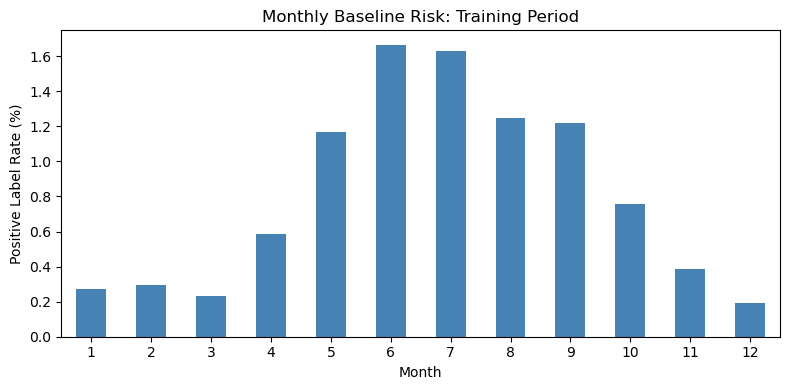

In [17]:
%pip install scikit-learn

from sklearn.metrics import average_precision_score, brier_score_loss

data = analysis_panel.copy()
data["month"] = data["date"].dt.month

# Training labels end before the test period begins
train = data.loc[data["date"] <= "2017-12-28"].copy()
test = data.loc[data["date"] >= "2018-01-01"].copy()

y_train = train["fire_next_3days"].astype(int)
y_test = test["fire_next_3days"].astype(int)

# Baseline 1: one constant probability learned from training data
base_rate = y_train.mean()
constant_prediction = np.full(len(test), base_rate)

# Baseline 2: monthly probabilities learned only from training data
month_rates = train.groupby("month")["fire_next_3days"].mean()
monthly_prediction = (
    test["month"].map(month_rates).fillna(base_rate).astype(float)
)

results = pd.DataFrame({
    "baseline": ["Constant probability", "Monthly probability"],
    "average_precision": [
        average_precision_score(y_test, constant_prediction),
        average_precision_score(y_test, monthly_prediction)
    ],
    "brier_score": [
        brier_score_loss(y_test, constant_prediction),
        brier_score_loss(y_test, monthly_prediction)
    ]
})

print("Training cell-days:", len(train))
print("Test cell-days:", len(test))
print(f"Test positive rate: {y_test.mean():.4%}")
display(results.round(6))

ax = month_rates.astype(float).mul(100).plot(
    kind="bar", figsize=(8, 4), color="steelblue"
)
ax.set_title("Monthly Baseline Risk: Training Period")
ax.set_xlabel("Month")
ax.set_ylabel("Positive Label Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The temporal evaluation uses 2011–2017 for training and 2018–2020 for testing. Training rows whose three-day outcome windows cross into the test period are excluded. The test positive rate is 0.7017%. A monthly probability baseline achieves an average precision of 0.011565, compared with 0.007017 for the constant baseline. Brier scores are similar (0.006954 versus 0.006968). These results suggest that seasonality provides some predictive information, but they do not establish reliable pre-ignition warning. The outcome represents recorded discoveries during the next three calendar days, rather than verified ignition times. Spatial generalization remains untested.